# Handling Imbalanced Dataset using SMOTE

In this notebook, we will explore the Synthetic Minority Over-sampling Technique (SMOTE) to handle imbalanced datasets. We will demonstrate how to apply SMOTE to a sample dataset and evaluate its effectiveness.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# Set random seed for reproducibility
np.random.seed(42)

In [2]:
# Load the dataset
data = pd.read_csv('../datasets/red_wine.csv')
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.00,0.00,1.0,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.47,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


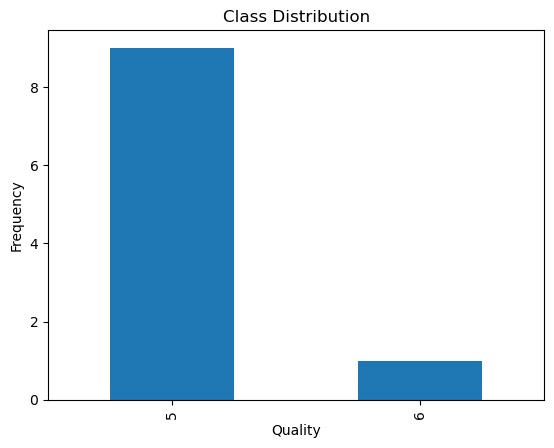

In [3]:
# Check the class distribution
class_distribution = data['quality'].value_counts()
class_distribution.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Quality')
plt.ylabel('Frequency')
plt.show()

In [9]:
# Split the data into features and target
X = data.drop('quality', axis=1)
y = data['quality']

# Oversample the minority class using SMOTE
# Dynamically set k_neighbors to avoid ValueError
minority_class_count = class_distribution.min()
k_neighbors_value = min(5, minority_class_count - 1) if minority_class_count > 1 else 1
smote = SMOTE(random_state=42, k_neighbors=k_neighbors_value)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Ensure the resampled data is stratified during the train-test split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

ValueError: Expected n_neighbors <= n_samples_fit, but n_neighbors = 2, n_samples_fit = 1, n_samples = 1

In [10]:
# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check the new class distribution
new_class_distribution = pd.Series(y_train_resampled).value_counts()
new_class_distribution.plot(kind='bar')
plt.title('New Class Distribution after SMOTE')
plt.xlabel('Quality')
plt.ylabel('Frequency')
plt.show()

NameError: name 'X_train' is not defined

In [11]:
# Train a Random Forest Classifier on the resampled data
model = RandomForestClassifier(random_state=42)
model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print(classification_report(y_test, y_pred))
confusion_matrix_result = confusion_matrix(y_test, y_pred)
sns.heatmap(confusion_matrix_result, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

NameError: name 'X_train_resampled' is not defined